In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Original Datasets
train_df_path = "./helmet_detection_train.csv"
test_df_path = "./helmet_detection_test.csv"
val_df_path = "./helmet_detection_validation.csv"

train_df = pd.read_csv(train_df_path)
test_df = pd.read_csv(test_df_path)
val_df = pd.read_csv(val_df_path)

# Deduplicated Datasets
train_df_deduplicated_path = "../dataset-yolo-compatible/dataframes/helmet_detection_train_deduplicated.csv"
test_df_deduplicated_path = "../dataset-yolo-compatible/dataframes/helmet_detection_test_deduplicated.csv"
val_df_deduplicated_path = "../dataset-yolo-compatible/dataframes/helmet_detection_validation_deduplicated.csv"

train_df_deduplicated = pd.read_csv(train_df_deduplicated_path)
test_df_deduplicated = pd.read_csv(test_df_deduplicated_path)
val_df_deduplicated = pd.read_csv(val_df_deduplicated_path)

In [2]:
train_df.head()

,image_name,label,track_id,x1,y1,x2,y2
0,Bago_highway_11_01,DNoHelmet,_msurfy1df,1481,605,1549,714
1,Bago_highway_11_02,DNoHelmet,_msurfy1df,1475,605,1543,714
2,Bago_highway_11_03,DNoHelmet,_msurfy1df,1469,605,1536,714
3,Bago_highway_11_04,DNoHelmet,_msurfy1df,1463,605,1530,715
4,Bago_highway_11_05,DNoHelmet,_msurfy1df,1457,605,1524,715


In [3]:
train_df_deduplicated.head()

,image_name,label,track_id,x1,y1,x2,y2,image_only
0,Bago_highway_11_01,1,_msurfy1df,1481,605,1549,714,Bago_highway_11
1,Bago_highway_11_100,0,_kj96uh9tz,831,637,927,826,Bago_highway_11
2,Bago_highway_11_16,0,_kj96uh9tz,943,626,1050,796,Bago_highway_11
3,Bago_highway_11_16,1,_msurfy1df,1388,596,1453,706,Bago_highway_11
4,Bago_highway_11_26,1,_n0a1jjoqv,1815,569,1920,696,Bago_highway_11


In [4]:
def reduce_to_violation(text: str):
    if "NoHelmet" in text:
        return "1" # Violation
    else:
        return "0" # No Violation

train_df["label"] = train_df["label"].apply(reduce_to_violation).astype("int64")
test_df["label"] = test_df["label"].apply(reduce_to_violation).astype("int64")
val_df["label"] = val_df["label"].apply(reduce_to_violation).astype("int64")

## Classes Count pre-post deduplication

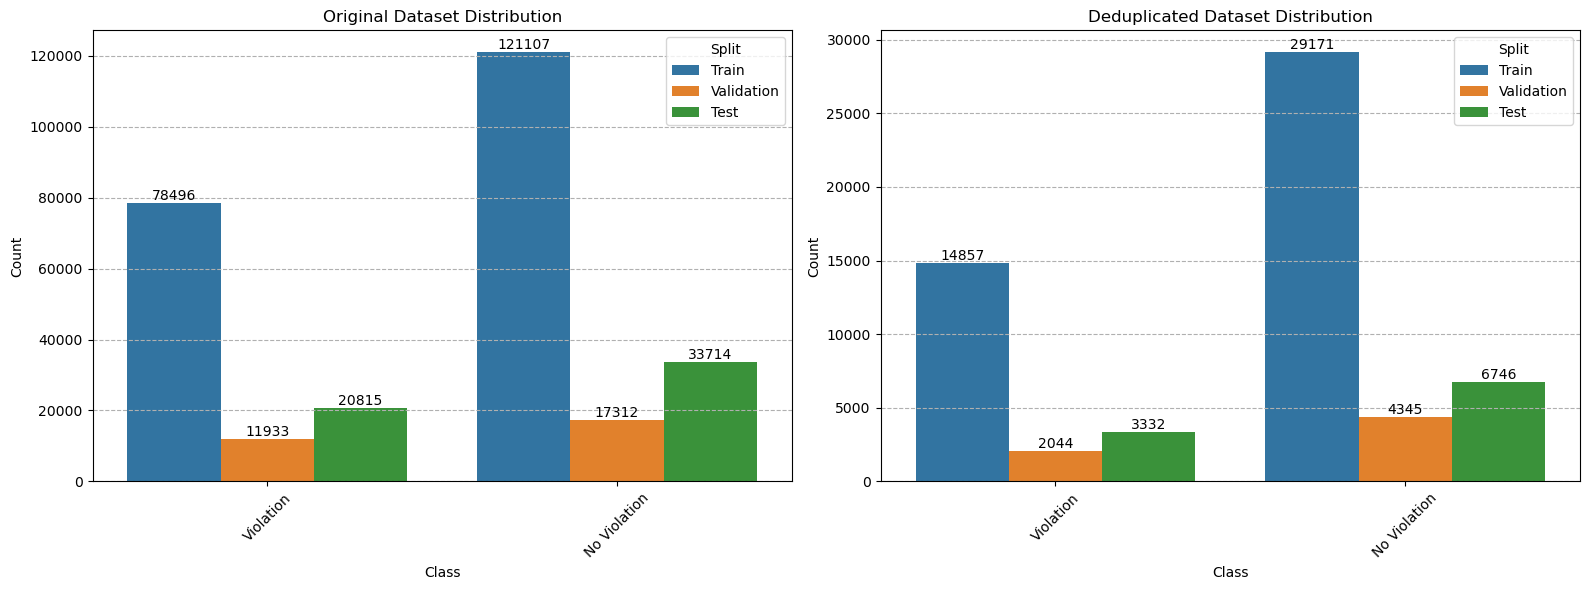

In [9]:
# Original Data
train_df['Split'], val_df['Split'], test_df['Split'] = 'Train', 'Validation', 'Test'
original_combined = pd.concat([train_df, val_df, test_df])
original_combined['Class_Label'] = original_combined['label'].map({0: 'No Violation', 1: 'Violation'})

# Deduplicated Data
train_df_deduplicated['Split'] = 'Train'
val_df_deduplicated['Split'] = 'Validation'
test_df_deduplicated['Split'] = 'Test'
dedup_combined = pd.concat([train_df_deduplicated, val_df_deduplicated, test_df_deduplicated])
dedup_combined['Class_Label'] = dedup_combined['label'].map({0: 'No Violation', 1: 'Violation'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Original Dataset
sns.countplot(ax=axes[0], data=original_combined, x='Class_Label', hue='Split')
axes[0].set_title('Original Dataset Distribution')
for container in axes[0].containers:
    axes[0].bar_label(container)

# Deduplicated Dataset
sns.countplot(ax=axes[1], data=dedup_combined, x='Class_Label', hue='Split')
axes[1].set_title('Deduplicated Dataset Distribution')
for container in axes[1].containers:
    axes[1].bar_label(container)

#Global labels and layout
for ax in axes:
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig("./images/deduplication_distribution.jpg")
plt.show()

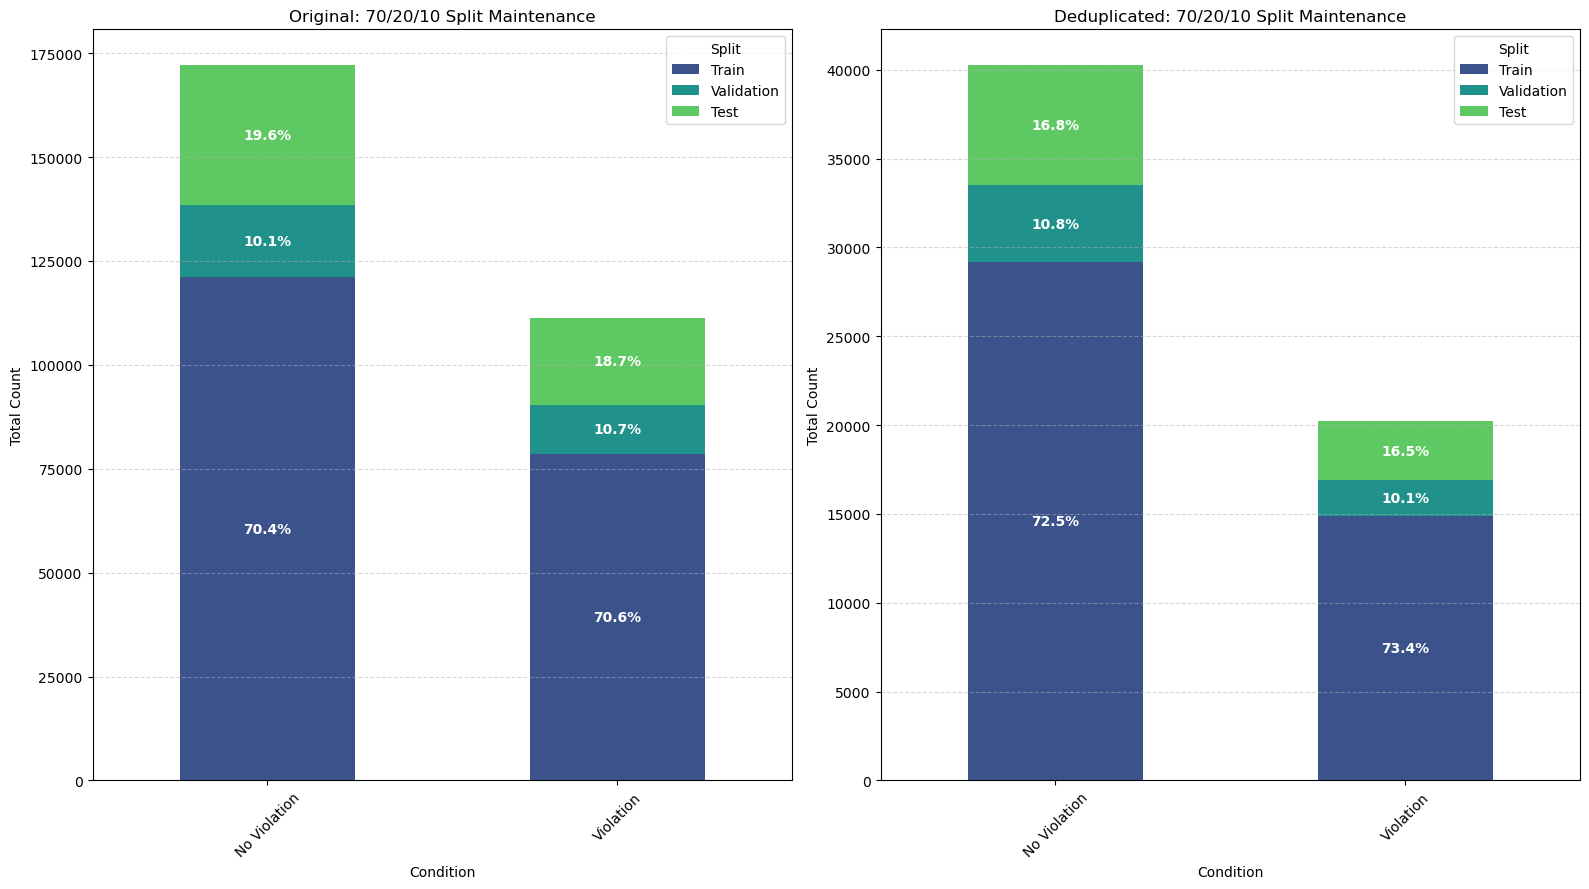

In [16]:
# Split preservance Check
def get_stacked_data(df):
    pivot_df = df.groupby(['Class_Label', 'Split']).size().unstack(fill_value=0)
    cols = [c for c in ['Train', 'Validation', 'Test'] if c in pivot_df.columns]
    return pivot_df[cols]

original_stacked = get_stacked_data(original_combined)
dedup_stacked = get_stacked_data(dedup_combined)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
palette = sns.color_palette("viridis", 3)

# Original
original_stacked.plot(kind='bar', stacked=True, ax=axes[0], color=palette)
axes[0].set_title('Original: 70/20/10 Split Maintenance')

# Deduplicated
dedup_stacked.plot(kind='bar', stacked=True, ax=axes[1], color=palette)
axes[1].set_title('Deduplicated: 70/20/10 Split Maintenance')

# Add Percentage Labels inside segments
for ax, data in zip(axes, [original_stacked, dedup_stacked]):
    # Get total height for each bar to calculate percentage
    totals = data.sum(axis=1)
    
    for i, container in enumerate(ax.containers):
        labels = []
        for j, v in enumerate(container):
            height = v.get_height()
            if height > 0:
                percentage = (height / totals.iloc[j]) * 100
                labels.append(f'{percentage:.1f}%')
            else:
                labels.append('')
        
        # Add the calculated labels to the center of each segment
        ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Condition')
    ax.set_ylabel('Total Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("./images/split_maintainence.jpg")
plt.show()